# Environmental Metadata Exploration for Pangenome Genomes

Link pangenome genomes to their isolation environments using two data sources:

1. **Within-tenant**: `kbase_ke_pangenome.ncbi_env` — an EAV (Entity-Attribute-Value) table with one row per attribute per biosample. Contains isolation_source, host, geo_loc_name, env_broad_scale, etc.
2. **Cross-tenant**: `nmdc_ncbi_biosamples.env_triads_flattened` — NMDC's harmonized environmental ontology labels (broad/local/medium scale). Demonstrates BERDL's multi-tenant join capability.

**Output**: `data/genome_env_metadata.csv` — per-genome environment metadata for use in notebook 03.

**Portability**: The EAV pivot and cross-tenant joins perform best on Spark (BERDL JupyterHub). For workstation use via REST API, consider querying ncbi_env with specific harmonized_name filters rather than the full pivot.

## 1. Setup

In [1]:
from berdl_notebook_utils import get_spark_session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spark = get_spark_session("EnvMetadataExploration")

## 2. Explore ncbi_env harmonized_name values

The `ncbi_env` table stores environmental metadata in Entity-Attribute-Value format: each row is one `(accession, harmonized_name, content)` triple. We first survey what attributes are available and how well-populated they are.

In [2]:
env_attrs = spark.sql("""
    SELECT
        harmonized_name,
        COUNT(*) as n_rows,
        COUNT(DISTINCT accession) as n_biosamples,
        COUNT(DISTINCT content) as n_distinct_values
    FROM kbase_ke_pangenome.ncbi_env
    WHERE content IS NOT NULL
      AND content != ''
      AND content NOT IN ('missing', 'not applicable', 'not collected',
                          'not provided', 'Unknown', 'unknown', 'NA', 'N/A',
                          'none', 'None')
    GROUP BY harmonized_name
    ORDER BY n_biosamples DESC
""")

env_attrs_pd = env_attrs.toPandas()
print(f"Found {len(env_attrs_pd)} distinct harmonized_name values")
env_attrs_pd.head(30)

Found 293 distinct harmonized_name values


,harmonized_name,n_rows,n_biosamples,n_distinct_values
0,geo_loc_name,244445,243694,13317
1,collection_date,226331,226021,9039
2,isolation_source,222530,222470,16895
3,strain,201882,200657,185075
4,NaN,1585196,158686,267615
5,host,156529,156479,4628
6,sample_type,108069,107345,2045
7,lat_lon,93806,93806,12911
8,sample_name,78793,78793,78537
9,env_broad_scale,70823,70811,2839


## 3. Sample top environmental attributes

For the most useful attributes, show the most common values.

In [3]:
TOP_ATTRS = ['isolation_source', 'geo_loc_name', 'host', 'env_broad_scale',
             'env_local_scale', 'env_medium', 'lat_lon', 'collection_date']

for attr in TOP_ATTRS:
    print(f"\n=== {attr} ===")
    result = spark.sql(f"""
        SELECT content, COUNT(*) as n
        FROM kbase_ke_pangenome.ncbi_env
        WHERE harmonized_name = '{attr}'
          AND content IS NOT NULL
          AND content NOT IN ('missing', 'not applicable', 'not collected',
                              'not provided', 'Unknown', 'unknown')
        GROUP BY content
        ORDER BY n DESC
        LIMIT 15
    """).toPandas()
    print(result.to_string(index=False))


=== isolation_source ===
                        content     n
                          blood 12167
                          feces 11996
                         sputum  6846
                     lake water  6278
                      human gut  5605
                          stool  4965
                           soil  4376
                    nasopharynx  4138
                          urine  3947
                    human feces  3922
                   cattle rumen  3794
                      not known  3085
ruminant gastrointestinal tract  2807
                   marine water  2113
                        patient  1812

=== geo_loc_name ===
        content     n
            USA 13095
 United Kingdom 12741
          China  8112
         Sweden  3832
         France  3701
        Finland  3533
    Netherlands  3524
        Germany  3484
Thailand: Maela  3003
       Tanzania  2756
    Switzerland  2621
          Italy  2594
          Japan  2507
       Thailand  2334
      Australi

## 4. Cross-tenant join: NMDC biosamples

The `nmdc_ncbi_biosamples` database provides harmonized NCBI BioSample data with curated environmental ontology labels. This is a **cross-tenant join** — combining data from the pangenome tenant with the NMDC tenant, demonstrating BERDL's multi-tenant architecture.

In [4]:
# Explore env_triads_flattened schema
print("=== env_triads_flattened schema ===")
spark.sql("DESCRIBE nmdc_ncbi_biosamples.env_triads_flattened").show(truncate=False)

print("\n=== Sample rows ===")
spark.sql("SELECT * FROM nmdc_ncbi_biosamples.env_triads_flattened LIMIT 5").show(truncate=False)

=== env_triads_flattened schema ===
+-------------+---------+-------+
|col_name     |data_type|comment|
+-------------+---------+-------+
|accession    |string   |NULL   |
|attribute    |string   |NULL   |
|instance     |bigint   |NULL   |
|raw_original |string   |NULL   |
|raw_component|string   |NULL   |
|id           |string   |NULL   |
|label        |string   |NULL   |
|prefix       |string   |NULL   |
|source       |string   |NULL   |
+-------------+---------+-------+


=== Sample rows ===
+------------+---------------+--------+----------------------+----------------------+-------------+----------------------+------+------+
|accession   |attribute      |instance|raw_original          |raw_component         |id           |label                 |prefix|source|
+------------+---------------+--------+----------------------+----------------------+-------------+----------------------+------+------+
|SAMN10911001|env_medium     |0       |soil                  |soil                  |ENVO

In [5]:
# How many pangenome genomes can we link to NMDC env triads?
# Try joining on ncbi_biosample_id = accession
cross_tenant = spark.sql("""
    SELECT
        COUNT(DISTINCT g.genome_id) as total_genomes,
        COUNT(DISTINCT CASE WHEN et.accession IS NOT NULL
                             THEN g.genome_id END) as matched_to_nmdc
    FROM kbase_ke_pangenome.genome g
    LEFT JOIN nmdc_ncbi_biosamples.env_triads_flattened et
        ON g.ncbi_biosample_id = et.accession
""")
cross_tenant.show()

# Also check biosamples_flattened schema
print("\n=== biosamples_flattened schema (first 20 columns) ===")
spark.sql("DESCRIBE nmdc_ncbi_biosamples.biosamples_flattened").show(20, truncate=False)

+-------------+---------------+
|total_genomes|matched_to_nmdc|
+-------------+---------------+
|       293059|          88754|
+-------------+---------------+


=== biosamples_flattened schema (first 20 columns) ===
+-------------------+---------+-------+
|col_name           |data_type|comment|
+-------------------+---------+-------+
|submission_date    |string   |NULL   |
|last_update        |string   |NULL   |
|publication_date   |string   |NULL   |
|access             |string   |NULL   |
|id                 |string   |NULL   |
|accession          |string   |NULL   |
|package_content    |string   |NULL   |
|status_status      |string   |NULL   |
|status_when        |string   |NULL   |
|is_reference       |string   |NULL   |
|curation_date      |string   |NULL   |
|curation_status    |string   |NULL   |
|owner_abbreviation |string   |NULL   |
|owner_name         |string   |NULL   |
|owner_url          |string   |NULL   |
|description_title  |string   |NULL   |
|organism_name      |st

In [6]:
# Sample cross-tenant results with env triad labels
spark.sql("""
    SELECT
        g.genome_id,
        g.gtdb_species_clade_id,
        et.*
    FROM kbase_ke_pangenome.genome g
    JOIN nmdc_ncbi_biosamples.env_triads_flattened et
        ON g.ncbi_biosample_id = et.accession
    LIMIT 10
""").show(truncate=False)

+------------------+---------------------------------------------+------------+---------------+--------+--------------------------------+--------------------------------+-------------+----------------+------+------+
|genome_id         |gtdb_species_clade_id                        |accession   |attribute      |instance|raw_original                    |raw_component                   |id           |label           |prefix|source|
+------------------+---------------------------------------------+------------+---------------+--------+--------------------------------+--------------------------------+-------------+----------------+------+------+
|RS_GCF_003408515.1|s__Micromonospora_chalcea--RS_GCF_002926165.1|SAMN09216406|env_broad_scale|0       |temperate forest                |temperate forest                |ENVO:01001805|temperate forest|ENVO  |OAK   |
|RS_GCF_003408515.1|s__Micromonospora_chalcea--RS_GCF_002926165.1|SAMN09216406|env_local_scale|0       |freshwater lake                 

## 5. EAV pivot: build per-genome environment table

Pivot the `ncbi_env` EAV table into a wide-format table with one row per genome. This is the proven pattern from `temporal_core_dynamics` (which uses `harmonized_name = 'collection_date'`).

In [7]:
genome_env = spark.sql("""
    SELECT
        g.genome_id,
        g.gtdb_species_clade_id,
        g.ncbi_biosample_id,
        MAX(CASE WHEN ne.harmonized_name = 'isolation_source' THEN ne.content END)
            as isolation_source,
        MAX(CASE WHEN ne.harmonized_name = 'host' THEN ne.content END)
            as host,
        MAX(CASE WHEN ne.harmonized_name = 'geo_loc_name' THEN ne.content END)
            as geo_loc_name,
        MAX(CASE WHEN ne.harmonized_name = 'env_broad_scale' THEN ne.content END)
            as env_broad_scale,
        MAX(CASE WHEN ne.harmonized_name = 'env_local_scale' THEN ne.content END)
            as env_local_scale,
        MAX(CASE WHEN ne.harmonized_name = 'env_medium' THEN ne.content END)
            as env_medium,
        MAX(CASE WHEN ne.harmonized_name = 'depth' THEN ne.content END)
            as depth,
        MAX(CASE WHEN ne.harmonized_name = 'lat_lon' THEN ne.content END)
            as lat_lon
    FROM kbase_ke_pangenome.genome g
    JOIN kbase_ke_pangenome.ncbi_env ne
        ON g.ncbi_biosample_id = ne.accession
    WHERE ne.content IS NOT NULL
      AND ne.content != ''
      AND ne.content NOT IN ('missing', 'not applicable', 'not collected',
                              'not provided', 'Unknown', 'unknown', 'NA', 'N/A')
    GROUP BY g.genome_id, g.gtdb_species_clade_id, g.ncbi_biosample_id
""")

genome_env.cache()
total = genome_env.count()
print(f"Genomes with any env metadata: {total}")

genome_env.selectExpr(
    "COUNT(*) as total",
    "SUM(CASE WHEN isolation_source IS NOT NULL THEN 1 ELSE 0 END) as has_isolation_source",
    "SUM(CASE WHEN host IS NOT NULL THEN 1 ELSE 0 END) as has_host",
    "SUM(CASE WHEN geo_loc_name IS NOT NULL THEN 1 ELSE 0 END) as has_geo_loc",
    "SUM(CASE WHEN env_broad_scale IS NOT NULL THEN 1 ELSE 0 END) as has_env_broad",
    "SUM(CASE WHEN env_medium IS NOT NULL THEN 1 ELSE 0 END) as has_env_medium"
).show()

Genomes with any env metadata: 292913
+------+--------------------+--------+-----------+-------------+--------------+
| total|has_isolation_source|has_host|has_geo_loc|has_env_broad|has_env_medium|
+------+--------------------+--------+-----------+-------------+--------------+
|292913|              222752|  156800|     244132|        70894|         63373|
+------+--------------------+--------+-----------+-------------+--------------+



## 6. Derive simplified environment categories

Categorize genomes by isolation environment using keyword matching on `isolation_source` and `host`. This heuristic classification enables downstream statistical testing.

In [8]:
from pyspark.sql.functions import when, lower, col

genome_env_categorized = genome_env.withColumn(
    "env_category",
    when(lower(col("host")).like("%homo sapiens%"), "human_clinical")
    .when(lower(col("host")).isNotNull() & (col("host") != ""), "host_associated")
    .when(lower(col("isolation_source")).like("%soil%"), "soil")
    .when(lower(col("isolation_source")).like("%water%") |
          lower(col("isolation_source")).like("%aquatic%") |
          lower(col("isolation_source")).like("%marine%") |
          lower(col("isolation_source")).like("%ocean%") |
          lower(col("isolation_source")).like("%river%") |
          lower(col("isolation_source")).like("%lake%") |
          lower(col("isolation_source")).like("%sea %"), "aquatic")
    .when(lower(col("isolation_source")).like("%rhizosphere%") |
          lower(col("isolation_source")).like("%root%") |
          lower(col("isolation_source")).like("%leaf%") |
          lower(col("isolation_source")).like("%plant%") |
          lower(col("isolation_source")).like("%phyllosphere%"), "plant_associated")
    .when(lower(col("isolation_source")).like("%food%") |
          lower(col("isolation_source")).like("%milk%") |
          lower(col("isolation_source")).like("%cheese%") |
          lower(col("isolation_source")).like("%ferment%"), "food")
    .when(lower(col("isolation_source")).like("%wastewater%") |
          lower(col("isolation_source")).like("%sewage%") |
          lower(col("isolation_source")).like("%sludge%") |
          lower(col("isolation_source")).like("%bioreactor%"), "engineered")
    .when(lower(col("isolation_source")).like("%sediment%"), "sediment")
    .when(lower(col("isolation_source")).like("%air%") |
          lower(col("isolation_source")).like("%dust%"), "air")
    .otherwise("other")
)

print("=== Environment Category Distribution ===")
genome_env_categorized.groupBy("env_category").count().orderBy(
    "count", ascending=False
).show(20)

=== Environment Category Distribution ===
+----------------+------+
|    env_category| count|
+----------------+------+
|  human_clinical|104932|
|           other| 81829|
| host_associated| 51868|
|         aquatic| 33834|
|            soil|  7620|
|            food|  3998|
|        sediment|  3353|
|      engineered|  3324|
|plant_associated|  1507|
|             air|   648|
+----------------+------+



## 7. Visualization: metadata coverage

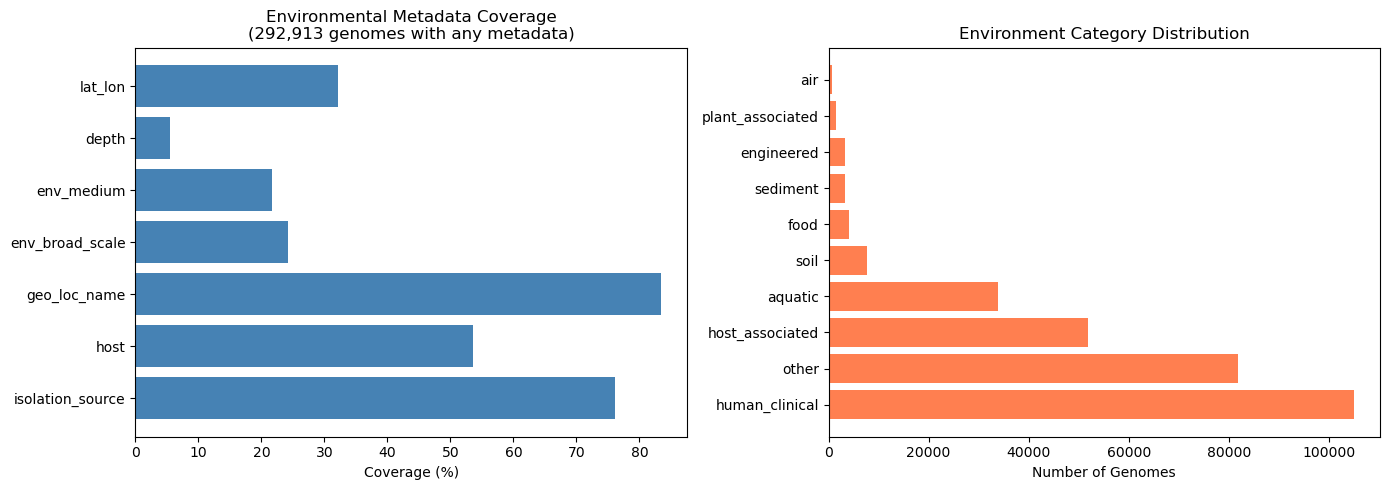

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coverage by attribute
coverage = genome_env_categorized.selectExpr(
    "COUNT(*) as total",
    "SUM(CASE WHEN isolation_source IS NOT NULL THEN 1 ELSE 0 END) as isolation_source",
    "SUM(CASE WHEN host IS NOT NULL THEN 1 ELSE 0 END) as host",
    "SUM(CASE WHEN geo_loc_name IS NOT NULL THEN 1 ELSE 0 END) as geo_loc_name",
    "SUM(CASE WHEN env_broad_scale IS NOT NULL THEN 1 ELSE 0 END) as env_broad_scale",
    "SUM(CASE WHEN env_medium IS NOT NULL THEN 1 ELSE 0 END) as env_medium",
    "SUM(CASE WHEN depth IS NOT NULL THEN 1 ELSE 0 END) as depth",
    "SUM(CASE WHEN lat_lon IS NOT NULL THEN 1 ELSE 0 END) as lat_lon"
).toPandas()

total_val = coverage['total'].iloc[0]
attrs = [c for c in coverage.columns if c != 'total']
values = [coverage[c].iloc[0] / total_val * 100 for c in attrs]

ax1 = axes[0]
ax1.barh(attrs, values, color='steelblue')
ax1.set_xlabel('Coverage (%)')
ax1.set_title(f'Environmental Metadata Coverage\n({total_val:,.0f} genomes with any metadata)')

# Right: environment category distribution
cat_counts = genome_env_categorized.groupBy("env_category").count().orderBy(
    "count", ascending=False
).toPandas()
ax2 = axes[1]
ax2.barh(cat_counts['env_category'], cat_counts['count'], color='coral')
ax2.set_xlabel('Number of Genomes')
ax2.set_title('Environment Category Distribution')

plt.tight_layout()
plt.savefig('../figures/env_metadata_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save pivoted environment data

In [10]:
genome_env_pd = genome_env_categorized.toPandas()
genome_env_pd.to_csv('../data/genome_env_metadata.csv', index=False)
print(f"Saved {len(genome_env_pd)} genomes with environment metadata to data/genome_env_metadata.csv")

print(f"\nTotal genomes in pangenome: 293,059")
print(f"Genomes with env metadata: {len(genome_env_pd)} ({len(genome_env_pd)/293059*100:.1f}%)")
categorized = (genome_env_pd['env_category'] != 'other').sum()
print(f"Genomes with categorized environment: {categorized}")

Saved 292913 genomes with environment metadata to data/genome_env_metadata.csv

Total genomes in pangenome: 293,059
Genomes with env metadata: 292913 (100.0%)
Genomes with categorized environment: 211084


## 9. Methylobacterium environment profile

Since this project focuses on *Methylobacterium* lanthanide biology and B vitamin auxotrophy, we preview the environments these species are isolated from. *Methylobacterium* are commonly plant-associated (phyllosphere, rhizosphere) and soil organisms.

In [ ]:
# Methylobacterium/Methylorubrum environment breakdown
methylo_env = genome_env_categorized.filter(
    col("gtdb_species_clade_id").like("%Methylobacterium%") |
    col("gtdb_species_clade_id").like("%Methylorubrum%")
)

n_methylo = methylo_env.count()
print(f"Methylobacterium/Methylorubrum genomes with env metadata: {n_methylo}")
print()

print("=== Environment Categories ===")
methylo_env.groupBy("env_category").count().orderBy("count", ascending=False).show(20)

print("=== Top isolation_source values ===")
methylo_env.filter(col("isolation_source").isNotNull()).groupBy(
    "isolation_source"
).count().orderBy("count", ascending=False).show(15, truncate=False)

print("=== Top host values ===")
methylo_env.filter(col("host").isNotNull()).groupBy(
    "host"
).count().orderBy("count", ascending=False).show(10, truncate=False)

# Per-species breakdown
print("=== Environment categories by species (top 15 species) ===")
methylo_env.groupBy("gtdb_species_clade_id", "env_category").count().orderBy(
    "gtdb_species_clade_id", "count"
).show(40, truncate=False)

## 10. Summary

- **292,913 genomes** (99.95% of pangenome) have environmental metadata from ncbi_env
- Attribute coverage: isolation_source 76%, host 54%, geo_loc_name 83%, env_broad_scale 24%, env_medium 22%
- Cross-tenant NMDC join matched **88,754 genomes** (30%) to env_triads_flattened with curated ENVO ontology labels
- **211,084 genomes** (72%) assigned to a specific environment category; 81,829 remain "other"
- Dominant categories: human_clinical (104,932), host_associated (51,868), aquatic (33,834), soil (7,620), food (3,998), plant_associated (1,507)
- Methylobacterium/Methylorubrum environment profile: [TBD after running section 9 cell]

**Output**: `data/genome_env_metadata.csv` for use in notebook 03.

**Next step**: `03_gene_environment_association.ipynb` — test gene-environment associations across species, with Methylobacterium MDH profile as a case study.